In [1]:
import pandas as pd
import numpy as np
import os
import math
from pathlib import Path
from matplotlib import pyplot as plt
import xarray as xr
from read_mym import read_mym_df
import warnings

from constants_BUMA import(
    SCENARIO_SELECT, FILE_ADDITION,
    REGIONS, REGIONS_RANGE,
    START_YEAR, END_YEAR, HIST_YEAR, YEARS, YEAR_LIST_SVA,
    INFLATION, 
    FLAG_ALPHA, FLAG_EXPDEC, FLAG_NORMAL,
    LOWCOMM,
    GOMPERTZ_EXPDEC,
    MINIMUM_COM
)
from lifetimes import compute_lifetimes
from floorspace import get_image_floorspace, extrapolate_floorspace, compute_housing_residential, compute_average_m2_capita, compute_housing_type
from population import compute_population



In [2]:
base_directory = Path("..", "IMAGE-Mat_old_version", "IMAGE-Mat", "BUMA")
database_directory = base_directory / "files_DB" / SCENARIO_SELECT
image_directory = base_directory / "files_IMAGE" / SCENARIO_SELECT
assert database_directory.is_dir(), database_directory
assert image_directory.is_dir()

In [3]:
# Lifetime computations, see lifetimes.py

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes_commercial, lifetimes_residential = compute_lifetimes(base_directory)

In [4]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb)


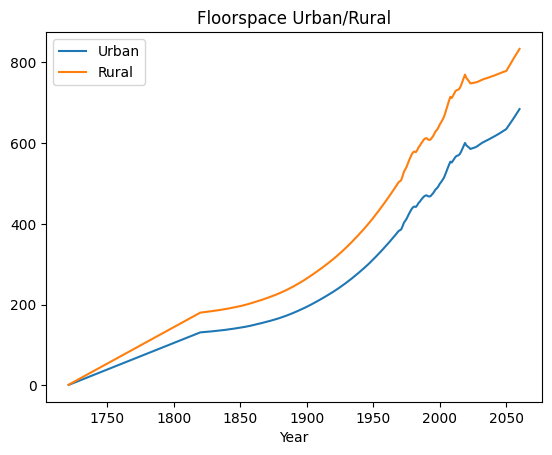

In [5]:
# Rural/Urban floorspace [Year, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})
floorspace_rururb.sum("Region").sel(Area="Urban").plot(label="Urban")
floorspace_rururb.sum("Region").sel(Area="Rural").plot(label="Rural")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

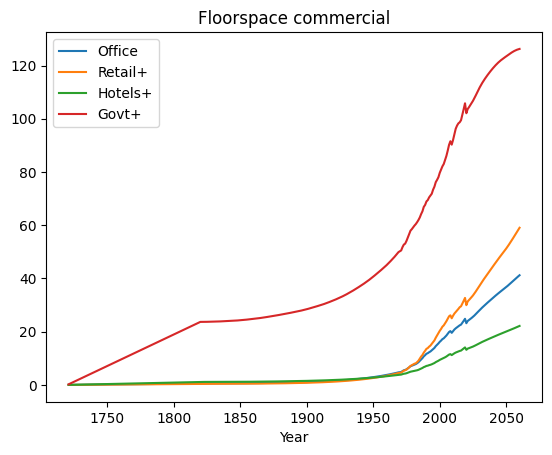

In [6]:
# Commercial floorspace [Year, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})
for commercial_type in floorspace_commercial.coords["Type"].values:
    floorspace_commercial.sum("Region").sel(Type=commercial_type).plot(label=commercial_type)
plt.legend()
plt.title("Floorspace commercial")
plt.show()

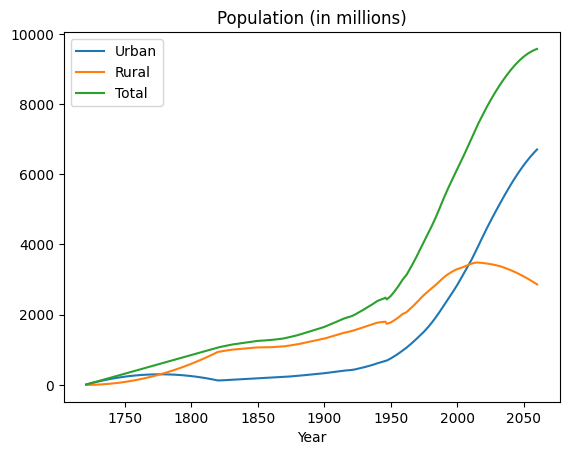

In [7]:
# Get the population data [Year, Region, Area].
population = compute_population(base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [8]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)

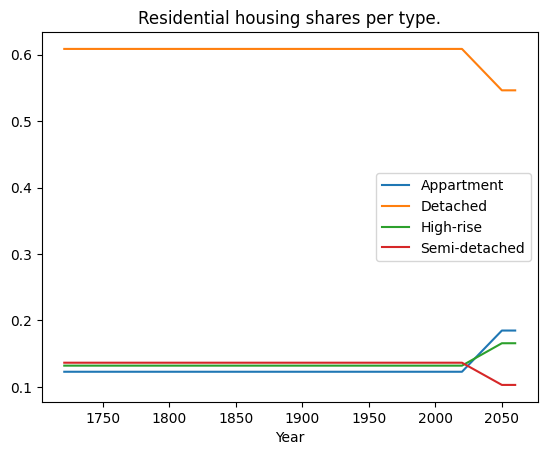

In [9]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

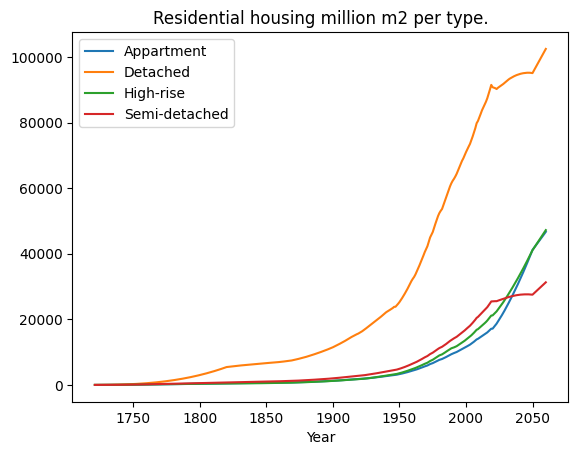

In [13]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, average_m2_capita, housing_type, floorspace_rururb)

for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()